<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 8, Time Series RAG**



1. Guarda "trozos" (ventanas) de una serie de tiempo histórica en una base de datos vectorial (simple, en memoria).
2. Cuando llega una nueva situación (una ventana reciente), recupera las situaciones históricas más parecidas.
3. Usa esas situaciones parecidas (lo que pasó después de ellas) para generar un pronóstico, en vez de aprender un modelo paramétrico complejo.

Esta idea es el equivalente, en series de tiempo, a lo que hace un RAG de texto:
en vez de que el modelo "invente" una respuesta de la nada, primero busca evidencia parecida
en una base de conocimiento y luego construye la respuesta apoyándose en esa evidencia.

**Dataset real:** temperaturas mínimas diarias en Melbourne, Australia (1981-1990), 3650 observaciones.


Importamos lo necesario

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cargamos el dataset real. Usaremos un dataset clásico y público de series de tiempo, el de la temperatura mínima diaria en Melbourne.


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=["Date"])
df = df.rename(columns={"Temp": "temperatura"})

print(f"Total de observaciones: {len(df)}")
df.head()

Total de observaciones: 3650


,Date,temperatura
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


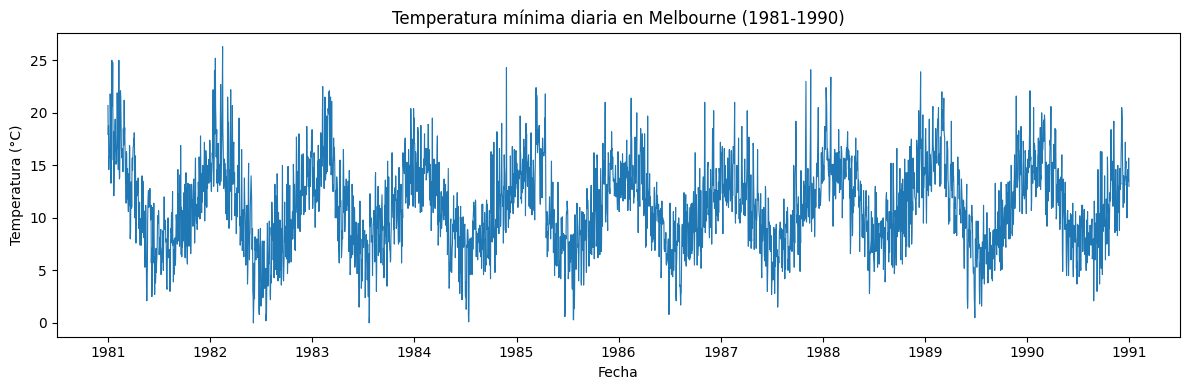

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["temperatura"], linewidth=0.8)
plt.title("Temperatura mínima diaria en Melbourne (1981-1990)")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


## A) Construcción de la Base de Conocimiento de Ventanas Históricas

* En un RAG de texto, la base de conocimiento son documentos o párrafos.
+ En un RAG de series de tiempo, la base de conocimiento son ventanas (fragmentos) de la serie histórica, cada una acompañada de lo que ocurrió justo después.

- WINDOW: cuántos días de historia miramos para describir una "situación" (el contexto).
- HORIZON: cuántos días hacia adelante queremos pronosticar (lo que buscamos "recuperar" como respuesta).

Cada ventana pasada queda guardada junto con su "continuación real", como si fuera
un par (pregunta, respuesta) en una base de RAG de texto.


In [ ]:
WINDOW = 30  # días de contexto que describen una "situación"
HORIZON = 7  # días que queremos pronosticar hacia adelante

In [ ]:
serie = df["temperatura"].values

In [ ]:
def crear_ventanas(serie, window, horizon):
    contextos, continuaciones = [], []
    for i in range(len(serie) - window - horizon + 1):
        contextos.append(serie[i:i+window])
        continuaciones.append(serie[i+window:i+window+horizon])
    return np.array(contextos), np.array(continuaciones)

contextos, continuaciones = crear_ventanas(serie, WINDOW, HORIZON)
print(f"Ventanas construidas: {contextos.shape[0]}")
print(f"Cada contexto tiene {contextos.shape[1]} días, cada continuación {continuaciones.shape[1]} días")

Ventanas construidas: 3614
Cada contexto tiene 30 días, cada continuación 7 días


* Guardamos, para cada ventana, el índice del último día que la ventana necesita conocer.
* La ventana i usa datos hasta la posición (i + WINDOW + HORIZON - 1): su continuación incluida.
* Este vector es lo que nos va a permitir filtrar el índice por tiempo en la sección C.

In [ ]:
fin_ventana = np.arange(len(contextos)) + WINDOW + HORIZON - 1

## B) "Embeddings" de cada ventana

* En texto, un embedding convierte una frase en un vector de números que representa su significado.
* Aquí hacemos algo conceptualmente parecido pero mucho más simple: convertimos cada ventana en un vector normalizado (le quitamos el nivel promedio y la escala).

* ¿Por qué normalizar? Porque queremos comparar la forma de la curva (sube, baja, hace zigzag),
no el valor absoluto. Así, un enero cálido se puede parecer a otro enero cálido de otro año
aunque los números exactos sean distintos.


In [ ]:
def normalizar_ventana(ventana):
    promedio = ventana.mean()
    desviacion = ventana.std() + 1e-8
    ventana_normalizada = (ventana - promedio) / desviacion
    return ventana_normalizada, promedio, desviacion

Convertimos toda la base histórica de ventanas en "embeddings" (vectores comparables)

In [ ]:
base_embeddings = np.array([normalizar_ventana(v)[0] for v in contextos])
print("Forma de la base de embeddings:", base_embeddings.shape)

Forma de la base de embeddings: (3614, 30)


## C) Retriever: buscar las situaciones históricas más parecidas

* Dada una ventana nueva (la situación actual), calculamos qué tan parecida es su forma a cada ventana guardada en la base, usando similitud coseno. Nos quedamos con las k más parecidas.

* La siguiente función devuelve indices y similitudes de las k ventanas históricas más parecidas.

* El corte es la posición en la serie que representa "hoy". Solo se pueden recuperar ventanas cuya continuación terminó antes de ese corte.

* El embedding consulta nos permite usar otra representación. Si es None, usa el z-score.

In [ ]:
def recuperar_analogos(ventana_consulta, base_embeddings, k=5, corte=None,
                       fin_ventana=fin_ventana, embedding_consulta=None):

    if embedding_consulta is None:
        consulta_normalizada, _, _ = normalizar_ventana(ventana_consulta)
    else:
        consulta_normalizada = embedding_consulta

    normas_base = np.linalg.norm(base_embeddings, axis=1)
    norma_consulta = np.linalg.norm(consulta_normalizada)
    similitudes = (base_embeddings @ consulta_normalizada) / (normas_base * norma_consulta + 1e-8)

    orden = np.argsort(-similitudes)  # de más a menos parecido

    if corte is not None:
        # Nos quedamos solo con ventanas del pasado (continuación incluida).
        # Esto también resuelve el solapamiento, porque una ventana que se solapa con la
        # consulta necesariamente termina después del corte.
        permitidas = fin_ventana < corte
        orden = orden[permitidas[orden]]

    mejores_indices = orden[:k]
    return mejores_indices, similitudes


## D) Generator: construir el pronóstico a partir de lo recuperado

* En un RAG de texto, el modelo generador redacta una respuesta usando los documentos recuperados como contexto.
* Nuestro generador es más simple pero sigue el mismo principio: promediamos lo que pasó después en cada una de las situaciones históricas más parecidas.
* Esto se llama pronóstico por análogos: en vez de asumir una fórmula matemática fija, dejamos que la historia (los datos recuperados) "vote" cuál es el futuro más probable.


La siguiente función combina las continuaciones de los análogos en un pronóstico (mediana + cuantiles)

In [ ]:
def generar_pronostico(indices_analogos, similitudes, ventana_actual,
                       cuantiles=(0.1, 0.5, 0.9), ponderar=True):

    _, mu_consulta, sigma_consulta = normalizar_ventana(ventana_actual)

    # Cada continuación se normaliza con los estadísticos de su propio contexto
    continuaciones_norm = np.array([
        (continuaciones[i] - contextos[i].mean()) / (contextos[i].std() + 1e-8)
        for i in indices_analogos
    ])

    # Los más parecidos pesan más (similitud elevada a 3 = más selectivo)
    if ponderar:
        pesos = np.clip(similitudes[indices_analogos], 0, None) ** 3
        pesos = pesos / pesos.sum() if pesos.sum() > 0 else np.ones(len(indices_analogos)) / len(indices_analogos)
    else:
        pesos = np.ones(len(indices_analogos)) / len(indices_analogos)

    # Al final se devuelve todo a la escala de la ventana actual
    media_norm = (continuaciones_norm * pesos[:, None]).sum(axis=0)
    pronostico = media_norm * sigma_consulta + mu_consulta

    # Cuantiles empíricos sobre los K análogos (sin supuesto gaussiano)
    q = {c: np.quantile(continuaciones_norm, c, axis=0) * sigma_consulta + mu_consulta
         for c in cuantiles}
    return pronostico, q

Tomamos como "situación actual" los últimos 30 días disponibles antes del tramo final, y comparamos el pronóstico contra lo que realmente ocurrió (para poder evaluar).

In [ ]:
posicion_consulta = len(serie) - WINDOW - HORIZON
ventana_actual = serie[posicion_consulta : posicion_consulta + WINDOW]
futuro_real   = serie[posicion_consulta + WINDOW : posicion_consulta + WINDOW + HORIZON]

In [ ]:
K = 5
CORTE = posicion_consulta + WINDOW    # "hoy" el último dato que el sistema conoce

indices_analogos, similitudes = recuperar_analogos(ventana_actual, base_embeddings, k=K, corte=CORTE)

In [ ]:
print("Índices de las situaciones históricas más parecidas:", indices_analogos)
print("Similitud de cada una:", [round(similitudes[i], 3) for i in indices_analogos])
print("Fechas de esos análogos:",
      [str(df.Date.iloc[i + WINDOW - 1].date()) for i in indices_analogos])

Índices de las situaciones históricas más parecidas: [  35 1631 3285 2527 3284]
Similitud de cada una: [np.float64(0.691), np.float64(0.69), np.float64(0.66), np.float64(0.654), np.float64(0.653)]
Fechas de esos análogos: ['1981-03-06', '1985-07-20', '1990-01-30', '1988-01-02', '1990-01-29']


El generador combina lo que pasó después en cada situación análoga

In [ ]:
pronostico_rag, cuantiles_rag = generar_pronostico(indices_analogos, similitudes, ventana_actual)

print("Pronóstico corregido (Time Series RAG):", np.round(pronostico_rag, 2))
print("Valor real                            :", np.round(futuro_real, 2))

Pronóstico corregido (Time Series RAG): [13.24 13.96 11.04 11.07 12.48 14.68 11.63]
Valor real                            : [12.9 14.6 14.  13.6 13.5 15.7 13. ]


## E) Visualizar: contexto, análogos recuperados y pronóstico

Esta grafica es el corazón de la idea de RAG aplicada a series de tiempo:
* mostramos la situación actual (línea sólida)
* las situaciones históricas parecidas que el sistema "recuperó" (líneas punteadas de fondo)
* el pronóstico que resulta de combinarlas
* el intervalo de predicción que surge de la dispersión entre los análogos


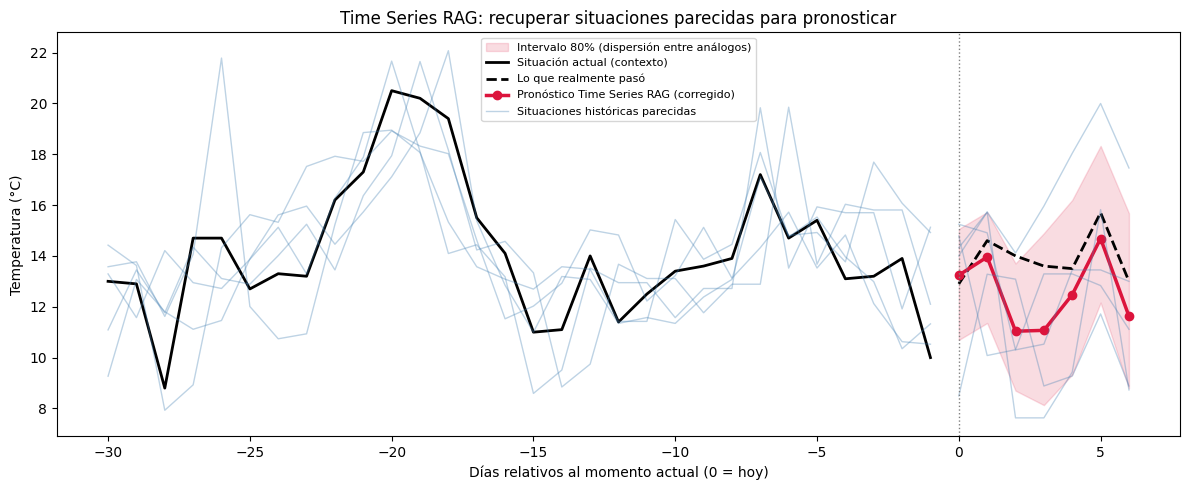

In [ ]:
plt.figure(figsize=(12, 5))
eje_contexto = np.arange(-WINDOW, 0)
eje_futuro   = np.arange(0, HORIZON)

# Intervalo empírico (Mejora 2)
plt.fill_between(eje_futuro, cuantiles_rag[0.1], cuantiles_rag[0.9], color="crimson", alpha=0.15,
                 label="Intervalo 80% (dispersión entre análogos)")

# Ventana actual (el query)
plt.plot(eje_contexto, ventana_actual, color="black", linewidth=2, label="Situación actual (contexto)")
# Futuro real
plt.plot(eje_futuro, futuro_real, color="black", linewidth=2, linestyle="--", label="Lo que realmente pasó")
# Pronóstico RAG corregido
plt.plot(eje_futuro, pronostico_rag, color="crimson", linewidth=2.5, marker="o",
         label="Pronóstico Time Series RAG (corregido)")

# Análogos recuperados (contexto + su continuación real), reescalados a la escala de la consulta
_, mu_q, sigma_q = normalizar_ventana(ventana_actual)
for i, idx in enumerate(indices_analogos):
    contexto_analogo = contextos[idx]
    continuacion_analoga = continuaciones[idx]
    analogo_normalizado, _, _ = normalizar_ventana(contexto_analogo)
    continuacion_normalizada = (continuacion_analoga - contexto_analogo.mean()) / (contexto_analogo.std() + 1e-8)
    analogo_reescalado = analogo_normalizado * sigma_q + mu_q
    continuacion_reescalada = continuacion_normalizada * sigma_q + mu_q

    etiqueta = "Situaciones históricas parecidas" if i == 0 else None
    plt.plot(eje_contexto, analogo_reescalado, color="steelblue", alpha=0.35, linewidth=1, label=etiqueta)
    plt.plot(eje_futuro, continuacion_reescalada, color="steelblue", alpha=0.35, linewidth=1)

plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.title("Time Series RAG: recuperar situaciones parecidas para pronosticar")
plt.xlabel("Días relativos al momento actual (0 = hoy)")
plt.ylabel("Temperatura (°C)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## F) Evaluar el pronóstico y comparar contra un baseline simple

* Para saber si el RAG realmente sirve, lo comparamos contra el Naive Baseline
* Usamos el error absoluto medio (MAE), que simplemente promedia qué tan lejos estuvo el pronóstico del valor real, en las mismas unidades


In [ ]:
def mae(pred, real):
    return np.mean(np.abs(np.array(pred) - np.array(real)))

pronostico_naive = np.repeat(ventana_actual[-1], HORIZON)

print(f"MAE Time Series RAG (k={K}): {mae(pronostico_rag, futuro_real):.2f}")
print(f"MAE baseline ingenuo (último valor)  : {mae(pronostico_naive, futuro_real):.2f}")

MAE Time Series RAG (k=5): 1.41
MAE baseline ingenuo (último valor)  : 3.90




**Ventajas de este enfoque:**
- Es interpretable: siempre puedes mostrar *qué* situaciones históricas motivaron el pronóstico.
- No requiere entrenar un modelo complejo, funciona directo sobre los datos históricos.
- Se adapta bien quando el pasado tiende a repetirse (estacionalidad, patrones climáticos, ciclos de demanda, etc.).

**Limitaciones:**
- Si ocurre algo nunca antes visto, no habrá buenos análogos que recuperar.
- La calidad depende mucho de cómo se construyen los "embeddings" de las ventanas.
- No captura tendencias de largo plazo tan bien como modelos especializados (ARIMA, Prophet, redes neuronales).
